# 👉 Illustrative Example for VCGC Flow
This is an illustrative example to demonstrate my proposed flow VCGC.
VCGC is primarily based on the idea of using state-of-the-art logic synthesis and reversible circuit logic with a layered approach that opens room for optimizations.

# 1. Creating a Vertex Coloring Problem Network (VCP)
This will read from the DIMACS.col files which contain the benchamrks and parse it to be a VCPNetwork object which contains the metadata of the graph and a NetworkX representation of the graph. This will serve as the input to both of the libraries.

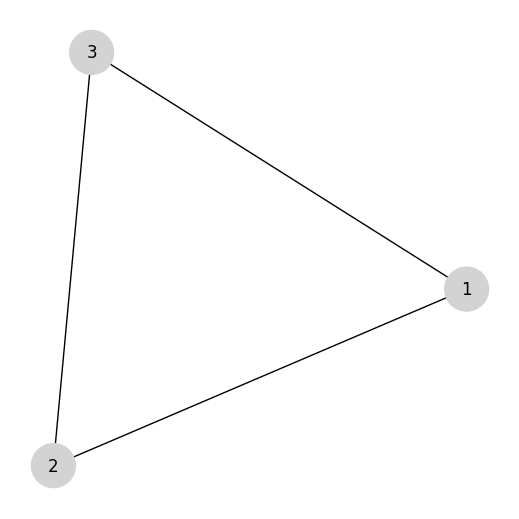

In [4]:
from vcgc.network import VCPNetwork
from IPython.display import display

draw_circuits: bool = False
out_dir: str = "../data/output/"
filename: str = "K3_example"
dimacs_filename: str = "../data/dev_data/dimacs/" + filename + ".col"

network = VCPNetwork(file_path=dimacs_filename)

graph_filename: str = out_dir + filename + ".png"
with open(graph_filename,"w+") as f:
    f.close()
    
# Display the graph
network.draw_graph(name=graph_filename, node_size=1000) # Draw nice graph using NetworkX

# 2. Extract the graph constraints

In [5]:
from vcgc.boolean import BooleanFunction

# Create Boolean function and display the constraints 
bf: BooleanFunction  = BooleanFunction()
bf.print_vertex_constraints(network=network)

(v1 != v2) ∧ (v1 != v3) ∧ (v2 != v3)



# 3. Generate the corresponding Logic Network

Generated multi-bit expression: ((v1_0 ^ v2_0) | (v1_1 ^ v2_1)) & ((v1_0 ^ v3_0) | (v1_1 ^ v3_1)) & ((v2_0 ^ v3_0) | (v2_1 ^ v3_1))
Variable order: ['v1_0', 'v1_1', 'v2_0', 'v2_1', 'v3_0', 'v3_1']
Verilog file written to: ../data/output/K3_example.v


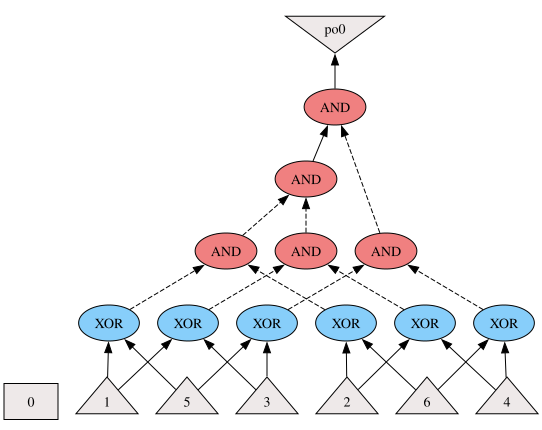

In [29]:
from tweedledum.bool_function_compiler.bool_function import BoolFunction
from tweedledum.classical import write_gate_dot, LogicNetwork
from graphviz import Source

# Generate tweedledum boolean function
tweedledum_bf: BoolFunction = bf.create_multi_bit_function(network=network, debug=True)
logic_network: LogicNetwork = tweedledum_bf.logic_network()

# Write to Verilog
verilog_filename: str = out_dir + filename + ".v"
bf.write_verilog_file(network=network, filename=verilog_filename)

dot_filename: str = out_dir + filename + ".dot"

# Create a file with filename if it does not exist
with open(file=dot_filename, mode="w+") as f:
    f.close()

write_gate_dot(logic_network, dot_filename)

# Read and display the dot file
with open(dot_filename, 'r') as f:
    dot_content = f.read()

# Create and display the graph
graph = Source(dot_content)
# graph.view()  # This will open in external viewer
display(graph)  # This will display inline in Jupyter notebook

# 4. Synthesize with XAG

In [7]:
from qiskit import QuantumCircuit
from vcgc.synthesis import Synthesizer

synthesizer: Synthesizer = Synthesizer(cf=tweedledum_bf)

oracle_circuit_xag: QuantumCircuit = synthesizer.synthesize_with_xag()
# To output the circuit as ASCII art:
synthesizer.print_circuit_info()


Number of qubits: 11
                                                                          »
__a10 : ──────────────────────────────────────────────────────────────────»
                                                                          »
 __a9 : ──────────────────────────────────────────────────────────────────»
                                                                          »
 __a8 : ──────────────────────────────────────────────────────────────────»
                            ╭────╮                                        »
 __a7 : ────────────────────┤ rx ├────────────────────────────────────────»
                            ╰─┬──╯                                        »
 __q6 : ──────────────────────┼───────────────────────────────────────────»
                              │                                 ╭────────╮»
 __q5 : ──────────────────────┼─────────────────────────────────┤ parity ├»
                              │                       ╭────────╮╰──

# 5. Create Uniform Superposition State Preparation Oracle to Filter Out Invalid Encodings

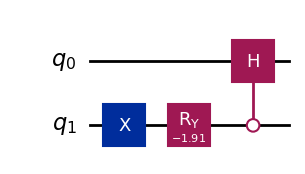

In [8]:
from vcgc.circuit import uniform_superposition_qiskit
from math import ceil, log2

num_superpos_states: int = network.available_colors
num_encode_qubits: int = ceil(log2(num_superpos_states)) # Leaving this here just for reference, it is done automatically
usp_oracle: QuantumCircuit = uniform_superposition_qiskit(num_superpos_states=num_superpos_states).decompose()

usp_oracle.draw(output="mpl")

# 6. Create the Respective Diffusion Operator

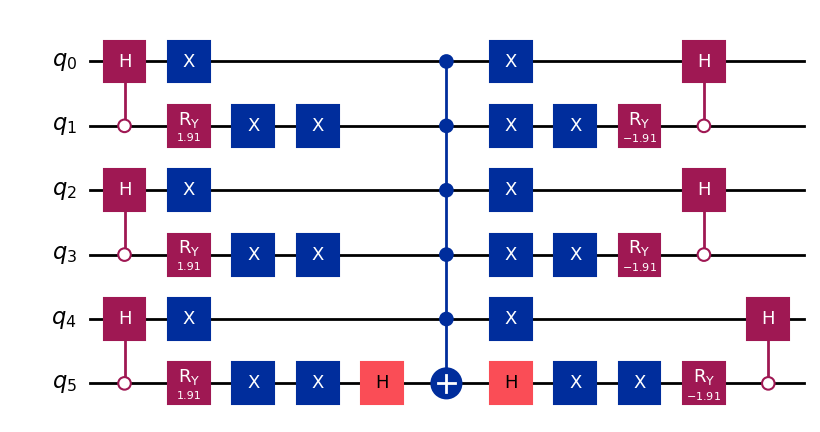

In [9]:
from vcgc.circuit import generate_grover_diffusion

num_data_qubits: int = network.num_vertices * num_encode_qubits
diff_oracle: QuantumCircuit = generate_grover_diffusion(num_qubits=num_data_qubits, uqs=usp_oracle)
display(diff_oracle.draw(output="mpl"))

# 7. Glue the Complete Grover Circuit Together

`VCGC` Grover Circuit:
Total qubits: 11
Circuit depth: 32
Number of gates: 79


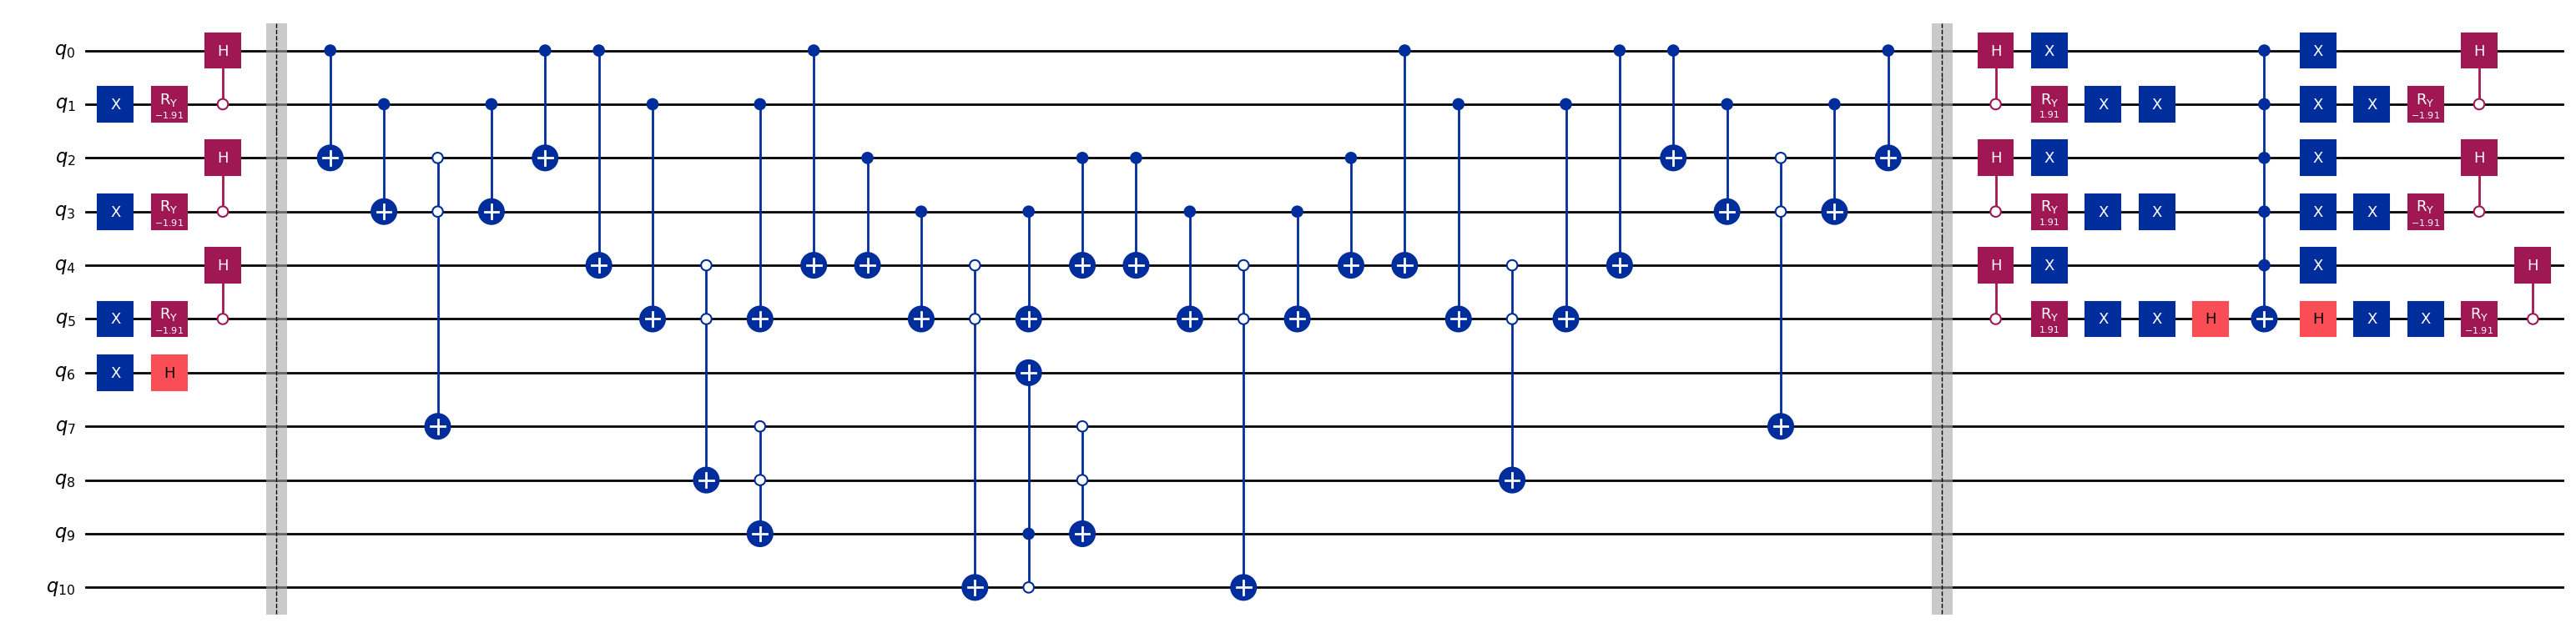

In [14]:
from vcgc.circuit import glue_grover_circuit
# Create the complete Grover circuit
vcgc_grover_circuit: QuantumCircuit = glue_grover_circuit(
    usp=usp_oracle,
    oracle=oracle_circuit_xag,
    diffusion=diff_oracle,
    num_data_qubits=num_data_qubits,
    num_encode_qubits=num_encode_qubits
)

# Display circuit information
print(f"`VCGC` Grover Circuit:")
print(f"Total qubits: {vcgc_grover_circuit.num_qubits}")
print(f"Circuit depth: {vcgc_grover_circuit.depth()}")
print(f"Number of gates: {len(vcgc_grover_circuit)}")

# Draw the circuit (might be large for complex graphs)
display(vcgc_grover_circuit.draw(output="mpl",fold=-1))

# 8. Simulate the Circuit

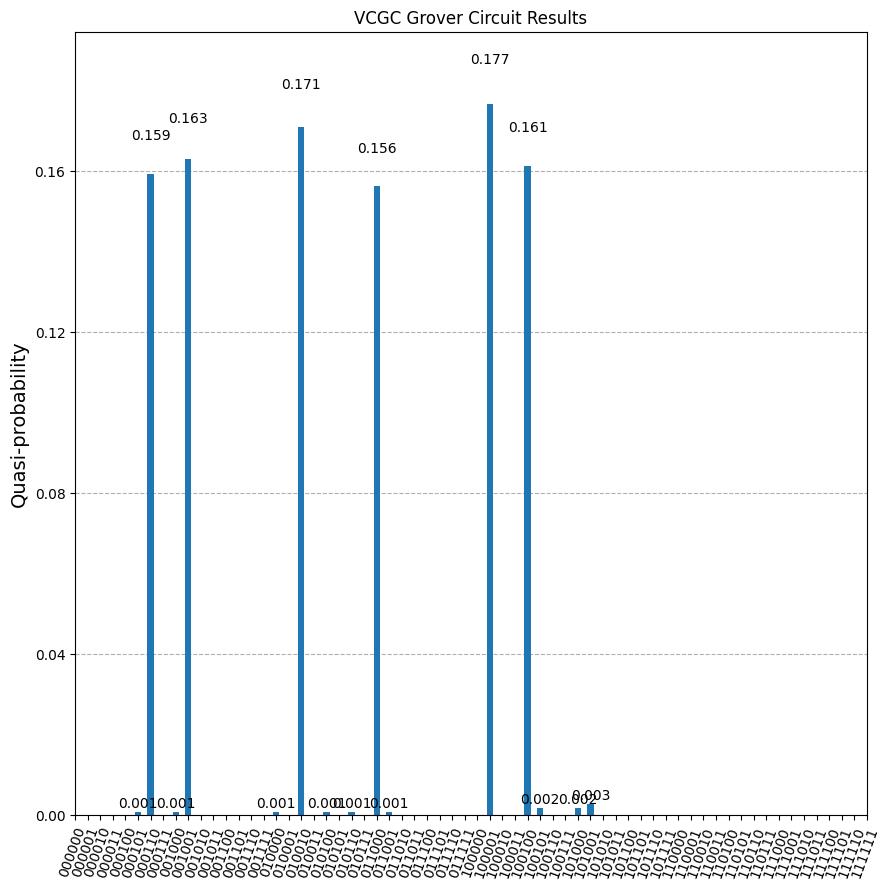

In [28]:
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit import transpile, ClassicalRegister

# Creating the backend
qasm_sim = Aer.get_backend('aer_simulator')

# A function to extract the counts of the useful qubits
def process_counts(counts, num_qubits):
    # New dictionary to store our results in.
    new_counts = {f'{i:0{num_qubits}b}': 0 for i in range(2**num_qubits)}

    # Loop through the counts dictionary, adding the value to the 
    # respective key in new_counts based on what state the show_qubit is in
    for count in counts:
        count_idx = (len(count) - num_qubits)
        new_counts[count[count_idx:count_idx+num_qubits]] += counts[count]
    
    return new_counts

# Create a copy of the circuit with measurements for the first 6 qubits only
qc_with_measurements = vcgc_grover_circuit.copy()

# Add classical register for 6 bits
classical_reg = ClassicalRegister(6, 'c')
qc_with_measurements.add_register(classical_reg)

# Measure only the first 6 qubits
for i in range(6):
    qc_with_measurements.measure(i, i)

# Transpile and run the circuit
qc_transpiled = transpile(qc_with_measurements, backend=qasm_sim)
result = qasm_sim.run(qc_transpiled).result()
counts = result.get_counts()

# Process the counts - now focusing on 6 qubits
counts_processed = process_counts(counts, num_qubits=6)

# print("Measurement results (probability distribution) for first 6 qubits:")
# for bitstring, count in counts_processed.items():
#     if count > 0:  # Only show non-zero counts
#         probability = count / sum(counts_processed.values())
#         print(f"|{bitstring}⟩: count = {count}, probability = {probability:.4f}")

# Plot the distribution
plot_distribution(counts_processed, title="VCGC Grover Circuit Results", figsize=(9,9))

# 9. Transpile the Circuit

In [27]:
from qiskit.transpiler import PassManager
from qiskit.circuit.library import XGate
from qiskit_ibm_runtime.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, DynamicCircuitInstructionDurations
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

least_busy_backend = service.least_busy(simulator=False, operational=True)

least_busy_target = least_busy_backend.target

durations = DynamicCircuitInstructionDurations.from_backend(backend=least_busy_backend)
 
optimized_pm = generate_preset_pass_manager(target=least_busy_target, optimization_level=3)
dd_rep = 8
dd_sequence = [XGate()] * dd_rep

optimized_pm.scheduling = PassManager([
    ALAPScheduleAnalysis(durations=durations),
    PadDynamicalDecoupling(
        durations=durations,
        dd_sequences=dd_sequence,
        pulse_alignment=16
    )
])

NUM_TRIAL = 10
vcgc_transpiled_circuits = []
for i in range(NUM_TRIAL):
    vcgc_transpiled_circuits.append(optimized_pm.run(vcgc_grover_circuit))

vcgc_depths = [circuit.depth() for circuit in vcgc_transpiled_circuits]
print("VCGC Circuit Depths:")
print(vcgc_depths)


VCGC Circuit Depths:
[1138, 1033, 931, 1073, 1164, 1093, 1038, 1054, 1045, 1094]
